# Trotter dynamics with Hamming-weight phasing

**Download Notebook** - {nb-download}`trotter_hamming_weight_phasing.ipynb`

This notebook compares two implementations of the same first-order Trotter step for the open-chain Ising Hamiltonian

$$H = J \sum_{i=0}^{n-2} Z_i Z_{i+1}. $$

The baseline uses `trotter_first_order`, which constructs one ordinary Pauli exponential per Zixy term. The second implementation groups the nearest-neighbor terms into even and odd brick-wall layers. Within each layer it computes all `ZZ` parities in parallel, replaces the identical `Rz` rotations with Hamming-weight phasing, and uncomputes the parities.

Because all terms in this simple Hamiltonian commute, first-order Trotterization is exact. This lets us isolate the effect of changing the circuit implementation.

In [1]:
from typing import no_type_check
import warnings

warnings.filterwarnings("ignore", category=SyntaxWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import zixy.qubit.pauli as zqp
from guppylang import guppy
from guppylang.defs import GuppyFunctionDefinition
from guppylang.std.angles import angle
from guppylang.std.builtins import array, comptime
from guppylang.std.debug import state_output
from guppylang.std.quantum import cx, discard_array, h, qubit
from selene_sim import Quest

from guppyalgos.primitives.arithmetic.hamming_weight import num_hamming_weight_bits
from guppyalgos.primitives.rotations.hamming_weight_phasing import hamming_weight_phase
from guppyalgos.algorithms.time_evolution.trotter import ham_sim_trotter, trotter_first_order
from guppyalgos.utils import qarray, transversal

## Build the nearest-neighbor Hamiltonian with Zixy

We use eight state qubits for the dynamics comparison. The Guppy angle convention implemented by `pauli_exp` gives $\exp[-i(\pi/2)\, J\, \Delta t\, Z_iZ_{i+1}]$ for each term.

In [2]:
N_STATE_QUBITS = 8
COUPLING = 0.7
TIME_STEP = 0.12
MAX_STEPS = 12


def nearest_neighbor_ising_hamiltonian(
    n_qubits: int, coupling: float
) -> zqp.RealTermSum:
    if n_qubits < 3:
        raise ValueError("This brick-wall example needs at least three qubits")
    source = ", ".join(
        f"({coupling}, Z{left} Z{left + 1})"
        for left in range(n_qubits - 1)
    )
    return zqp.RealTermSum.from_str(source, n_qubits)


hamiltonian = nearest_neighbor_ising_hamiltonian(
    N_STATE_QUBITS, COUPLING
)
hamiltonian

(0.7, Z0 Z1), (0.7, Z1 Z2), (0.7, Z2 Z3), (0.7, Z3 Z4), (0.7, Z4 Z5), (0.7, Z5 Z6), (0.7, Z6 Z7)

## Convert a Pauli-exponential step to brick-wall Hamming-weight phasing

For one edge, the ordinary `ZZ` Pauli exponential is

$$\operatorname{CX}_{i,i+1}\; R_z(\theta)_{i+1}\; \operatorname{CX}_{i,i+1}. $$

Edges in one brick-wall layer are disjoint, so their CX gates and parity targets can be handled together. If a layer contains $m$ identical rotations, Hamming-weight phasing replaces those $m$ arbitrary rotations with `num_hamming_weight_bits(m)` rotations, at the cost of reversible adders and clean ancillas.

In [3]:
def brick_wall_layers(
    hamiltonian: zqp.RealTermSum,
) -> tuple[tuple[tuple[int, int], ...], tuple[tuple[int, int], ...], float]:
    terms: list[zqp.RealTerm] = list(hamiltonian.to_terms())
    if not terms:
        raise ValueError("The Hamiltonian must contain at least one ZZ term")

    coupling = float(terms[0].coeff)
    even_edges: list[tuple[int, int]] = []
    odd_edges: list[tuple[int, int]] = []

    for term in terms:
        paulis = term.string.get_dict()
        support = tuple(sorted(paulis))
        if (
            len(support) != 2
            or support[1] != support[0] + 1
            or any(pauli != zqp.Z for pauli in paulis.values())
        ):
            raise ValueError("Expected only nearest-neighbor ZZ terms")
        if not np.isclose(float(term.coeff), coupling):
            raise ValueError("Hamming-weight phasing requires uniform coupling")
        (even_edges if support[0] % 2 == 0 else odd_edges).append(support)

    return tuple(even_edges), tuple(odd_edges), coupling


even_edges, odd_edges, _ = brick_wall_layers(hamiltonian)
print("Even layer:", even_edges)
print("Odd layer: ", odd_edges)

Even layer: ((0, 1), (2, 3), (4, 5), (6, 7))
Odd layer:  ((1, 2), (3, 4), (5, 6))


In [4]:
def hamming_weight_zz_layer(
    edges: tuple[tuple[int, int], ...],
    n_state_qubits: int,
) -> GuppyFunctionDefinition:
    n_edges = len(edges)
    phase_targets = hamming_weight_phase(n_edges)

    @guppy
    @no_type_check
    def layer(
        state_qreg: array[qubit, n_state_qubits], theta: angle
    ) -> None:
        lefts = comptime(array(left for left, _ in edges))
        rights = comptime(array(right for _, right in edges))
        controls = array(
            state_qreg.take(lefts[i]) for i in range(n_edges)
        )
        targets = array(
            state_qreg.take(rights[i]) for i in range(n_edges)
        )

        transversal(cx, controls, targets)
        phase_targets(targets, theta)
        transversal(cx, controls, targets)

        for i in range(n_edges):
            state_qreg.put(controls.take(i), lefts[i])
            state_qreg.put(targets.take(i), rights[i])
        controls.discard_all_taken()
        targets.discard_all_taken()

    return layer


def hamming_weight_ising_trotter_step(
    hamiltonian: zqp.RealTermSum,
    n_state_qubits: int,
) -> GuppyFunctionDefinition:
    even_edges, odd_edges, coupling = brick_wall_layers(hamiltonian)
    if not even_edges or not odd_edges:
        raise ValueError("Both brick-wall layers must be non-empty")

    even_layer = hamming_weight_zz_layer(even_edges, n_state_qubits)
    odd_layer = hamming_weight_zz_layer(odd_edges, n_state_qubits)

    @guppy
    @no_type_check
    def trotter_step(
        state_qreg: array[qubit, n_state_qubits], time_step: float
    ) -> None:
        theta = angle(comptime(coupling) * time_step)
        even_layer(state_qreg, theta)
        odd_layer(state_qreg, theta)

    return trotter_step


normal_step = trotter_first_order(hamiltonian, N_STATE_QUBITS)
hwp_step = hamming_weight_ising_trotter_step(
    hamiltonian, N_STATE_QUBITS
)

## Build the full dynamics with `ham_sim_trotter`

We prepare $|+\rangle^{\otimes n}$ and track the mean $X$ magnetization

$$\langle \bar X \rangle = \frac{1}{n}\sum_i \langle X_i \rangle. $$

For every time point, the Guppy circuit calls `ham_sim_trotter` with the requested number of steps. We use exactly the same helper for the ordinary and Hamming-weight-phased steps. The latter emulator is given enough capacity for the largest brick-wall layer's clean ancillas.

In [ ]:
def output_state(
    trotter_step: GuppyFunctionDefinition,
    n_steps: int,
    simulator_qubits: int,
) -> np.ndarray:
    @guppy
    @no_type_check
    def main() -> None:
        state_qreg = qarray(N_STATE_QUBITS)
        transversal(h, state_qreg)
        ham_sim_trotter(state_qreg, trotter_step, n_steps, TIME_STEP)
        state_output("state", state_qreg)
        discard_array(state_qreg)

    result = main.emulator(simulator_qubits).run()
    states = Quest.extract_states_dict(result.results[0].entries)
    return states["state"].get_single_state()


NORMAL_SIMULATOR_QUBITS = N_STATE_QUBITS
HWP_SIMULATOR_QUBITS = (
    N_STATE_QUBITS + max(len(even_edges), len(odd_edges))
)

In [ ]:
def mean_x(state: np.ndarray, n_qubits: int) -> float:
    indices = np.arange(state.size)
    expectations = [
        np.vdot(state, state[indices ^ (1 << qubit)]).real
        for qubit in range(n_qubits)
    ]
    return float(np.mean(expectations))


def max_error_up_to_global_phase(
    reference: np.ndarray, state: np.ndarray
) -> float:
    pivot = int(np.argmax(np.abs(reference)))
    phase = state[pivot] / reference[pivot]
    return float(np.max(np.abs(state - phase * reference)))


records = []
statevector_errors = []
for n_steps in range(MAX_STEPS + 1):
    normal_state = output_state(
        normal_step, n_steps, NORMAL_SIMULATOR_QUBITS
    )
    hwp_state = output_state(hwp_step, n_steps, HWP_SIMULATOR_QUBITS)
    statevector_errors.append(
        max_error_up_to_global_phase(normal_state, hwp_state)
    )
    records.append(
        {
            "step": n_steps,
            "time": n_steps * TIME_STEP,
            "Normal Pauli exponentials": mean_x(
                normal_state, N_STATE_QUBITS
            ),
            "Hamming-weight phasing": mean_x(
                hwp_state, N_STATE_QUBITS
            ),
        }
    )

dynamics = pd.DataFrame.from_records(records)
assert max(statevector_errors) < 1e-8
print(f"Maximum statevector error: {max(statevector_errors):.3e}")
dynamics

Maximum statevector error: 6.835e-15


,step,time,Normal Pauli exponentials,Hamming-weight phasing
0,0,0.00,1.000000,1.000000
1,1,0.12,0.940317,0.940317
2,2,0.24,0.775754,0.775754
3,3,0.36,0.545950,0.545950
4,4,0.48,0.305267,0.305267
5,5,0.60,0.108557,0.108557
6,6,0.72,-0.003023,-0.003023
7,7,0.84,-0.012361,-0.012361
8,8,0.96,0.069876,0.069876
9,9,1.08,0.209057,0.209057


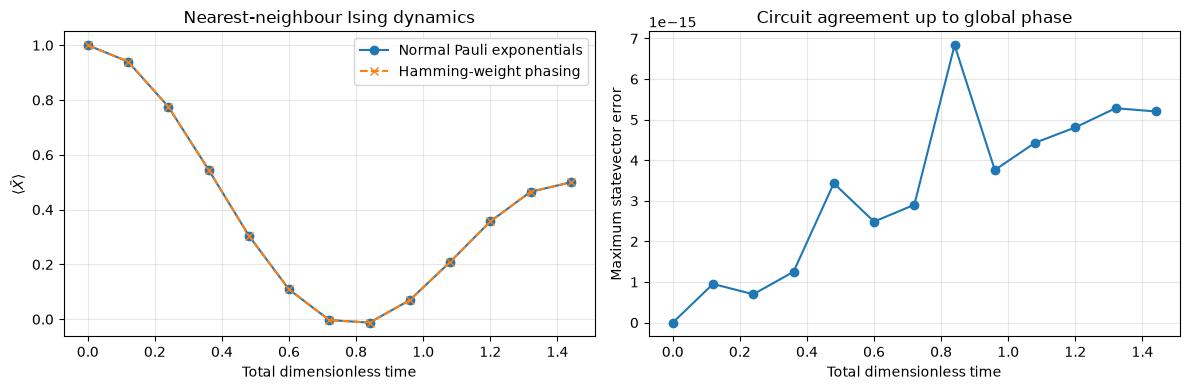

In [7]:
fig, (ax_dynamics, ax_error) = plt.subplots(1, 2, figsize=(12, 4))

ax_dynamics.plot(
    dynamics["time"],
    dynamics["Normal Pauli exponentials"],
    "o-",
    label="Normal Pauli exponentials",
)
ax_dynamics.plot(
    dynamics["time"],
    dynamics["Hamming-weight phasing"],
    "x--",
    label="Hamming-weight phasing",
)
ax_dynamics.set(
    xlabel="Total dimensionless time",
    ylabel=r"$\langle \bar X \rangle$",
    title="Nearest-neighbor Ising dynamics",
)
ax_dynamics.grid(alpha=0.3)
ax_dynamics.legend()

ax_error.plot(
    dynamics["time"],
    statevector_errors,
    "o-",
)
ax_error.set(
    xlabel="Total dimensionless time",
    ylabel="Maximum statevector error",
    title="Circuit agreement up to global phase",
)
ax_error.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## Arbitrary-rotation comparison

For an open chain, the ordinary step uses $n-1$ arbitrary `Rz` rotations. Hamming-weight phasing acts separately on the two brick-wall layers, so its count is the sum of the binary-register widths for the two layer sizes. The saving multiplies by the number of Trotter steps.

This is an arbitrary-rotation count, not a total gate count: Hamming-weight phasing introduces reversible addition/uncomputation and clean-ancilla requirements. It is most useful when synthesized arbitrary rotations are substantially more expensive than those extra operations.

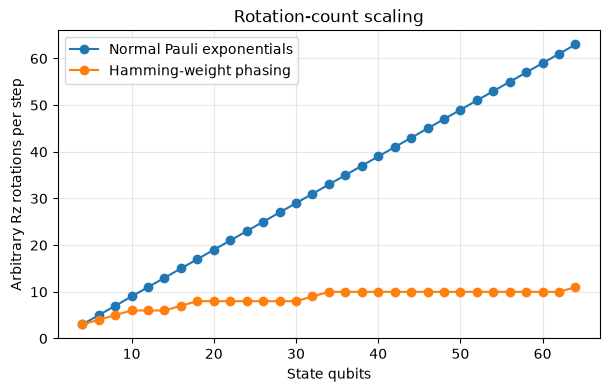

50-qubit step: 49 normal Rz -> 10 HWP Rz


In [8]:
def rotation_counts(n_state_qubits: int) -> tuple[int, int]:
    n_even = n_state_qubits // 2
    n_odd = (n_state_qubits - 1) // 2
    normal = n_even + n_odd
    hwp = (
        num_hamming_weight_bits(n_even)
        + num_hamming_weight_bits(n_odd)
    )
    return normal, hwp


chain_sizes = np.arange(4, 66, 2)
costs = pd.DataFrame(
    [
        {
            "qubits": n_qubits,
            "Normal Pauli exponentials": rotation_counts(n_qubits)[0],
            "Hamming-weight phasing": rotation_counts(n_qubits)[1],
        }
        for n_qubits in chain_sizes
    ]
)

ax = costs.plot(
    x="qubits",
    y=["Normal Pauli exponentials", "Hamming-weight phasing"],
    marker="o",
    figsize=(7, 4),
)
ax.set(
    xlabel="State qubits",
    ylabel="Arbitrary Rz rotations per step",
    title="Rotation-count scaling",
)
ax.grid(alpha=0.3)
plt.show()

normal_50, hwp_50 = rotation_counts(50)
print(f"50-qubit step: {normal_50} normal Rz -> {hwp_50} HWP Rz")